In [2]:
import pandas as pd
df=pd.read_csv(r"C:\Users\Vishnu\Desktop\Python_Evening\weather_football_decision_tree.csv")

In [3]:
df

,Outlook,Temperature,Humidity,Wind,Play_Football
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes
5,Rain,Cool,Normal,Strong,No
6,Overcast,Cool,Normal,Strong,Yes
7,Sunny,Mild,High,Weak,No
8,Sunny,Cool,Normal,Weak,Yes
9,Rain,Mild,Normal,Weak,Yes


In [4]:
df.head()

,Outlook,Temperature,Humidity,Wind,Play_Football
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes


In [5]:
df.isnull().sum()

Outlook          0
Temperature      0
Humidity         0
Wind             0
Play_Football    0
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Outlook        20 non-null     object
 1   Temperature    20 non-null     object
 2   Humidity       20 non-null     object
 3   Wind           20 non-null     object
 4   Play_Football  20 non-null     object
dtypes: object(5)
memory usage: 932.0+ bytes


In [8]:
df.shape

(20, 5)

In [9]:
df.nunique()

Outlook          3
Temperature      3
Humidity         2
Wind             2
Play_Football    2
dtype: int64

In [10]:
df.head()

,Outlook,Temperature,Humidity,Wind,Play_Football
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes


In [11]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

df['Outlook']=le.fit_transform(df['Outlook'])
df['Temperature']=le.fit_transform(df['Temperature'])
df['Humidity']=le.fit_transform(df['Humidity'])
df['Wind']=le.fit_transform(df['Wind'])
df['Play_Football']=le.fit_transform(df['Play_Football'])




In [12]:
df.head()

,Outlook,Temperature,Humidity,Wind,Play_Football
0,2,1,0,1,0
1,2,1,0,0,0
2,0,1,0,1,1
3,1,2,0,1,1
4,1,0,1,1,1


In [13]:
X=df.drop('Play_Football',axis=1)
y=df['Play_Football']

In [15]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
from sklearn.tree import DecisionTreeClassifier

model=DecisionTreeClassifier()
model.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [17]:
y_pred=model.predict(X_test)

In [18]:
print(y_pred)

[0 1 1 0]


In [25]:
from sklearn.metrics import accuracy_score

accuracy_score1=accuracy_score(y_test,y_pred)

In [26]:
print(accuracy_score1)

1.0


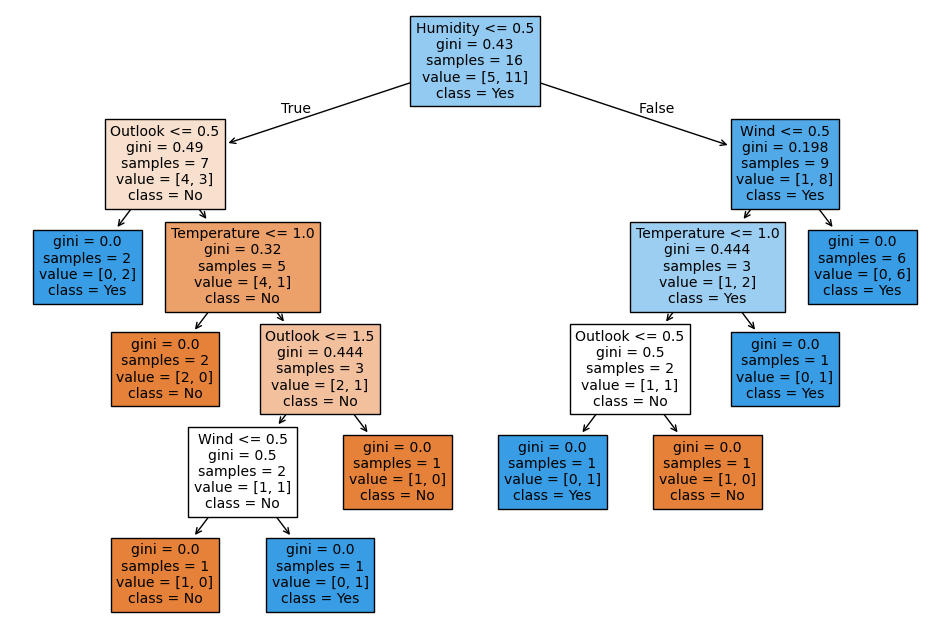

In [28]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt 

plt.figure(figsize=(12,8))

plot_tree(

    model,
    feature_names=X.columns,
    class_names=['No','Yes'],
    filled=True
)

plt.show()

In [29]:
df

,Outlook,Temperature,Humidity,Wind,Play_Football
0,2,1,0,1,0
1,2,1,0,0,0
2,0,1,0,1,1
3,1,2,0,1,1
4,1,0,1,1,1
5,1,0,1,0,0
6,0,0,1,0,1
7,2,2,0,1,0
8,2,0,1,1,1
9,1,2,1,1,1


In [39]:
N=0.3125
Y=0.6875


In [40]:
N=0.097
y=0.465

In [41]:
GINI=1-N+Y

In [42]:
GINI

1.5905

In [45]:
Entropy=-sigma Pi log2(Pi)

final Formula=


E=-p(Yes)log2 P(Yes)+P(NO)log2 p(No)


entropy range 0-1
0--perfect
0.5-Mixed
1- Higly Mixed

SyntaxError: invalid syntax (1036000698.py, line 1)

In [ ]:
records=10
Y=6
N=4

P(Y)=0.6
P(N)=0.4


E=-(0.6)log2 (0.6)+0.4 log2 (0.4)

In [ ]:
import math

yes=6
no=4

total=yes+no

pro_yes=yes/total
prob_no=no/total

entropy = -(pro_yes * math.log2(pro_yes) + prob_no * math.log2(prob_no))
print("Probability of Yes :", pro_yes)
print("Probability of No  :", prob_no)
print("log2(Yes)          :", math.log2(pro_yes))
print("log2(No)           :", math.log2(prob_no))
print("Entropy            :", round(entropy, 4))

Probability of Yes : 0.6
Probability of No  : 0.4
log2(Yes)          : -0.7369655941662062
log2(No)           : -1.3219280948873622
Entropy            : 0.971


  Customer_ID  Gender  Age       City  Occupation    Education Marital_Status  \
0    CUST0001    Male   58      Delhi  Government      Diploma         Single   
1    CUST0002    Male   23  Hyderabad  Freelancer  High School         Single   
2    CUST0003    Male   18    Chennai  Government     Graduate         Single   
3    CUST0004  Female   56      Delhi    Business  High School        Married   
4    CUST0005    Male   22  Hyderabad  Government  High School         Single   

  Income  Previous_Purchases  Discount_Offered(%) Product_Category  \
0    Low                   3                   50      Electronics   
1   High                  20                   50             Home   
2    Low                  10                    5      Electronics   
3    Low                  17                   20           Beauty   
4    Low                  12                   20             Home   

   Time_Spent_On_Website(min) Added_To_Cart Payment_Mode  Loyalty_Score  \
0                

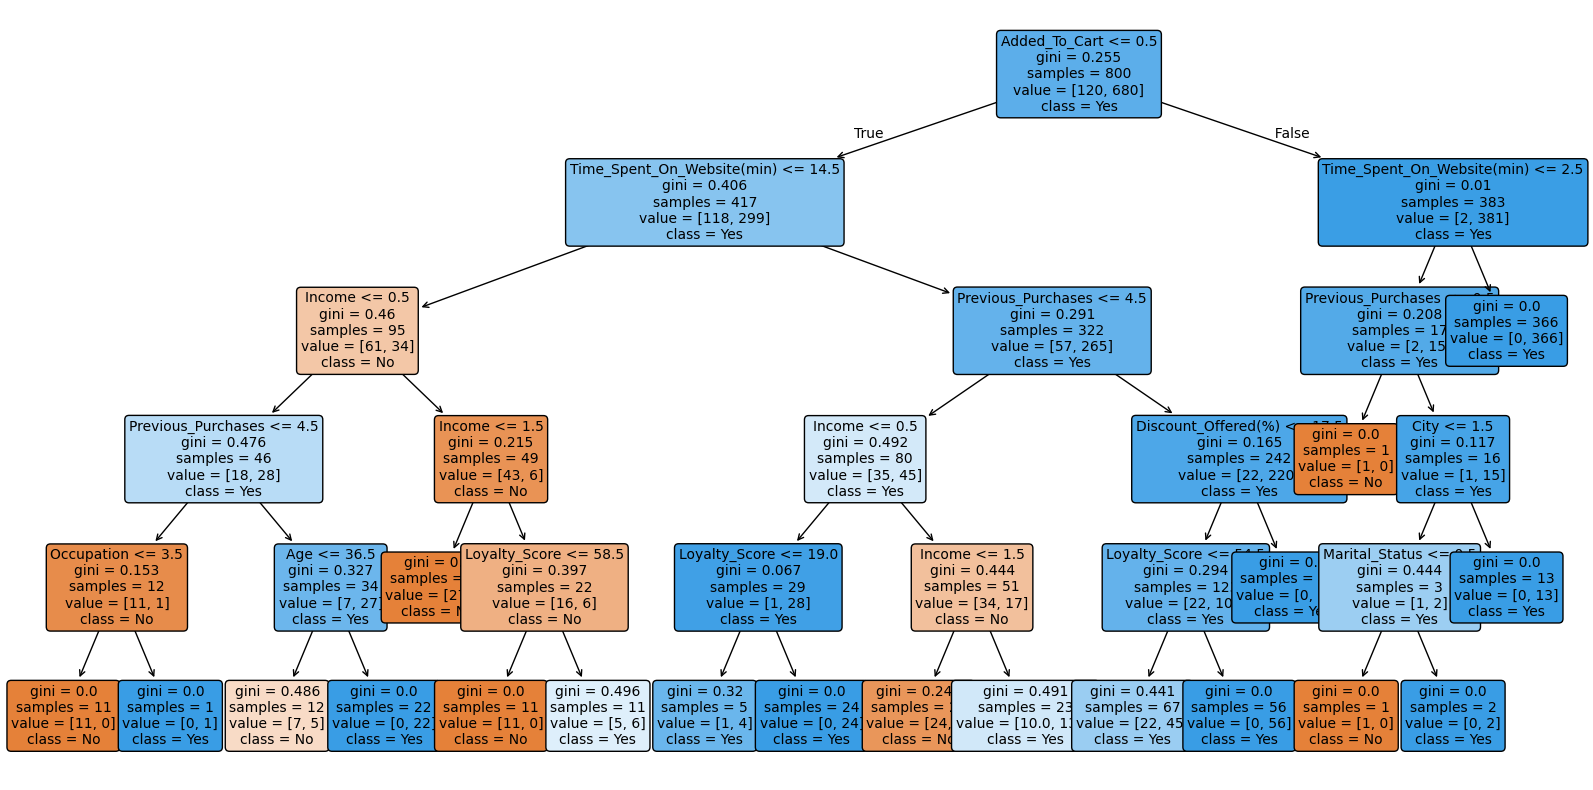

In [ ]:
# ===============================
# IMPORT LIBRARIES
# ===============================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# ===============================
# LOAD DATASET
# ===============================

df = pd.read_csv("Ecommerce_Customer_Dataset_1000.csv")

print(df.head())

# ===============================
# REMOVE CUSTOMER ID
# ===============================

df.drop("Customer_ID", axis=1, inplace=True)

# ===============================
# LABEL ENCODING
# ===============================

encoders = {}

for column in df.columns:

    if df[column].dtype == "object":

        encoder = LabelEncoder()

        df[column] = encoder.fit_transform(df[column])

        encoders[column] = encoder

print(df.head())

# ===============================
# SPLIT FEATURES & TARGET
# ===============================

X = df.drop("Purchased_Product", axis=1)

y = df["Purchased_Product"]

# ===============================
# TRAIN TEST SPLIT
# ===============================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.20,
    random_state=42

)

# ===============================
# CREATE MODEL
# ===============================

model = DecisionTreeClassifier(

    criterion="gini",
    max_depth=5,
    random_state=42

)

# ===============================
# TRAIN MODEL
# ===============================

model.fit(X_train, y_train)

# ===============================
# PREDICTION
# ===============================

y_pred = model.predict(X_test)

# ===============================
# ACCURACY
# ===============================

print()

print("Accuracy")

print(accuracy_score(y_test, y_pred))

# ===============================
# CONFUSION MATRIX
# ===============================

print()

print("Confusion Matrix")

print(confusion_matrix(y_test, y_pred))

# ===============================
# CLASSIFICATION REPORT
# ===============================

print()

print(classification_report(y_test, y_pred))

# ===============================
# FEATURE IMPORTANCE
# ===============================

importance = pd.DataFrame({

    "Feature": X.columns,
    "Importance": model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print()

print(importance)

# ===============================
# DECISION TREE VISUALIZATION
# ===============================

plt.figure(figsize=(20,10))

plot_tree(

    model,

    feature_names=X.columns,

    class_names=["No","Yes"],

    filled=True,

    rounded=True,

    fontsize=10

)

plt.show()

In [ ]:
def predict_customer_purchase(
    gender,
    age,
    city,
    occupation,
    education,
    marital_status,
    income,
    previous_purchases,
    discount_offered,
    product_category,
    website_time,
    added_to_cart,
    payment_mode,
    loyalty_score
):
    data = pd.DataFrame({

        "Gender":[gender],
        "Age":[age],
        "City":[city],
        "Occupation":[occupation],
        "Education":[education],
        "Marital_Status":[marital_status],
        "Income":[income],
        "Previous_Purchases":[previous_purchases],
        "Discount_Offered(%)":[discount_offered],
        "Product_Category":[product_category],
        "Time_Spent_On_Website(min)":[website_time],
        "Added_To_Cart":[added_to_cart],
        "Payment_Mode":[payment_mode],
        "Loyalty_Score":[loyalty_score]

    })
    # Encoding

    for column in data.columns:
        if column in encoders:
            data[column] = encoders[column].transform(data[column])

    prediction = model.predict(data)

    probability = model.predict_proba(data)

    if prediction[0] == 1:

        result = "Customer Will Purchase Product"

    else:

        result = "Customer Will NOT Purchase Product"

    print("\nPrediction :", result)

    print("Probability :", probability)

    return result

In [3]:
predict_customer_purchase(

    gender="Male",

    age=30,

    city="Delhi",

    occupation="Private",

    education="Graduate",

    marital_status="Single",

    income="Medium",

    previous_purchases=5,

    discount_offered=20,

    product_category="Electronics",

    website_time=25,

    added_to_cart="Yes",

    payment_mode="UPI",

    loyalty_score=75

)


Prediction : Customer Will Purchase Product
Probability : [[0. 1.]]


'Customer Will Purchase Product'